# Исследование алгоритмов численной оптимизации

Данный ноутбук представляет собой испытательный полигон для тестирования алгоритмов нулевого и первого порядка на различных целевых функциях, а также проверку их устойчивости при работе с интервальной арифметикой.


# Этап 1. Подготовка рабочего окружения

В этом разделе мы инициализируем среду для проведения экспериментов

In [1]:
import sys
import os
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('./src'))

In [16]:
# Импортируем необходимые классы и функции из src
from src.constructive_number import ConstructiveNumber
from src.black_box import IdealQuadraticFunction, BadConditionQuadraticFunction, RosenbrockFunction
from src.optimizers import GradientDescentOptimizer, NelderMeadOptimizer, to_real_value

# Настройка графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

# Этап 2. Калибровка алгоритмов на вещественных числах

Перед тем как вводить интервальную арифметику, необходимо убедиться в математической корректности самих алгоритмов

## 2.1. Идеальная квадратичная функция (Градиентный спуск)
* **Размерность**: 6
* **Число обусловленности**: $\kappa = 1$
* **Ожидание**: Быстрая и плавная сходимость метода первого порядка прямо в центр минимума

In [ ]:
# Создаем экземпляры нашей функции и оптимизатора

ideal_func = IdealQuadraticFunction()
gd_optimizer = GradientDescentOptimizer()

# Задаем стартовую точку (6-мерный вектор, намеренно отдаленный от нуля)
x0_ideal = [10.0, -10.0, 5.0, -5.0, 8.0, -8.0]

# Запускаем оптимизацию. Шаг обучения (alpha) берем 0.1
x_min_ideal = gd_optimizer.optimize(
    func = ideal_func, 
    x0 = x0_ideal, 
    learning_rate = 0.1, 
    max_iter = 300
)

# Выводим результаты
# Извлекаем скалярные значения перед округлением для успокоения Pylance
x_coords_real = [
    x.get_center() if isinstance(x, ConstructiveNumber) else float(x)
    for x in x_min_ideal
]
print("Найденная точка минимума:")
print([round(val, 6) for val in x_coords_real])

# Безопасно приводим значение функции для форматированного вывода :.8f
f_final = ideal_func(x_min_ideal)
f_final_val = f_final.get_center() if isinstance(f_final, ConstructiveNumber) else float(f_final)
print(f"Финальное значение функции: {f_final_val:.8f}")

Градиентный спуск успешно сошелся за 160 итераций (norm: 0.000001)
Найденная точка минимума (первые 4 координаты для краткости):
[0.0, -0.0, 0.0, -0.0, 0.0, -0.0] ...
Финальное значение функции: 0.00000000


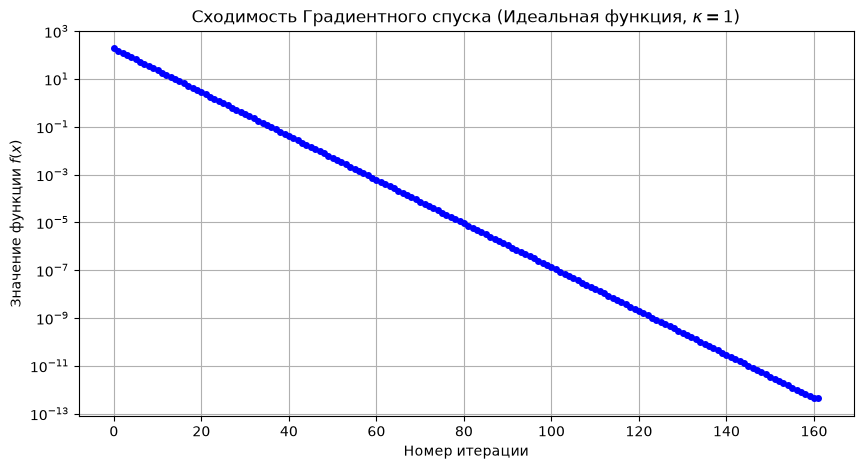

In [9]:
# Строим график сходимости
plt.figure(figsize=(10, 5))
plt.plot(gd_optimizer.history_f, marker='o', linestyle='-', color='b', markersize=4)
plt.title(r'Сходимость Градиентного спуска (Идеальная функция, $\kappa=1$)')
plt.xlabel('Номер итерации')
plt.ylabel('Значение функции $f(x)$')
plt.yscale('log')  # Логарифмическая шкала для наглядности
plt.show()

### Анализ результатов: Градиентный спуск ($\kappa = 1$)

* **Сходимость**: Алгоритм достиг критерия остановки ($\|\nabla f(x)\| < 10^{-6}$) за **160 итераций**
* **Точность**: Найденная точка $x^* \approx [0, 0, 0, 0, 0, 0]^T$ с точностью $10^{-8}$, финальное значение функции $f(x^*) = 0.0$.
* **Характер траектории**: 
  На полулогарифмическом графике $\log(f(x))$ зависимость представляет собой строго прямую линию. Это подтверждает теоретическую **линейную скорость сходимости** градиентного спуска на квадратичной функции:
  $$x_{k+1} = (I - \alpha A) x_k$$
  Для $\kappa = 1$ матрица $A = I$, поэтому сжатие расстояния до оптимума на каждом шаге происходит с постоянным коэффициентом $(1 - \alpha) = (1 - 0.1) = 0.9$, а значение функции убывает как геометрическая прогрессия со знаменателем $(1 - \alpha)^2 = 0.81$.

## 2.2. Овражная квадратичная функция (Метод Нелдера-Мида)

Теперь протестируем алгоритм нулевого порядка на функции с плохой обусловленностью ($\kappa = 100$).
* **Размерность**: 4
* **Особенности рельефа**: Линии уровня представляют собой сильно вытянутые эллипсоиды ("овраг"). По одной из осей функция растет в 100 раз быстрее, чем по другой.
* **Ожидание**: Симплекс метода Нелдера-Мида должен вытягиваться вдоль дна оврага и сжиматься у стенок, постепенно спускаясь к точке $(0, 0, 0, 0)$.

In [10]:
# Создаем экземпляры овражной функции и оптимизатора Нелдера-Мида
bad_func = BadConditionQuadraticFunction()
nm_optimizer = NelderMeadOptimizer()

# Задаем стартовую точку
x0_bad = [5.0, -5.0, 5.0, -5.0]

In [11]:
# Запускаем оптимизацию
x_min_bad = nm_optimizer.optimize(
    func = bad_func, 
    x0 = x0_bad, 
    step = 1.0, 
    max_iter = 1000
)

# Вывод результатов
x_bad_real = [
    x.get_center() if isinstance(x, ConstructiveNumber) else float(x)
    for x in x_min_bad
]
print("Найденная точка минимума:")
print([round(val, 6) for val in x_bad_real])

f_bad_final = bad_func(x_min_bad)
f_bad_val = f_bad_final.get_center() if isinstance(f_bad_final, ConstructiveNumber) else float(f_bad_final)
print(f"Финальное значение функции: {f_bad_val:.8f}")

Нелдер-Мид успешно сошелся за 122 итераций (diff: 0.00000057)
Найденная точка минимума:
[-0.000767, -9e-05, -5.7e-05, -3.6e-05]
Финальное значение функции: 0.00000060


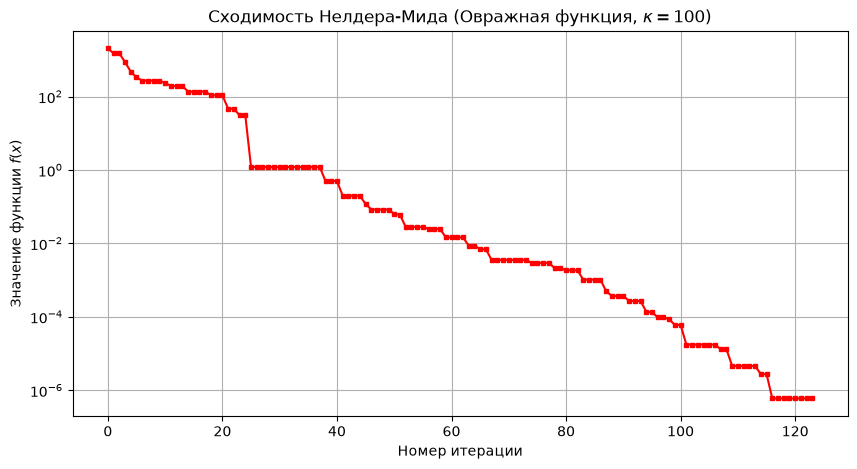

In [ ]:
# Строим график сходимости
plt.figure(figsize=(10, 5))
plt.plot(nm_optimizer.history_f, marker='s', linestyle='-', color='r', markersize=3)
plt.title(r'Сходимость Нелдера-Мида (Овражная функция, $\kappa=100$)')
plt.xlabel('Номер итерации')
plt.ylabel(r'Значение функции $f(x)$')
plt.yscale('log')
plt.show()

### Анализ результатов: Метод Нелдера-Мида (Овражная функция, $\kappa = 100$)

* **Сходимость**: Алгоритм выполнил критерий останова по сжатию симплекса за **122 итерации** 
* **Точность**: Найденная точка $x^* \approx [-0.0007, -0.00009, -0.00005, -0.00003]^T$. В отличие от градиентного спуска, метод нулевого порядка теряет ювелирную точность на самом дне плоского минимума, однако успешно находит его окрестность. Финальное значение $f(x^*) \approx 10^{-6}$.
* **Характер траектории**: 
  На графике ярко выражен **ступенчатый характер сходимости**. Ступеньки соответствуют итерациям, на которых алгоритм упирается в крутые стенки оврага. В эти моменты отражение не дает улучшения, и симплекс вынужден тратить шаги на операции **сжатия**, не улучшая лучшее значение функции. Как только многогранник адаптируется к форме дна, происходит резкий скачок вниз - операции растяжения вдоль оврага

## 2.3. Функция Розенброка (Сравнение алгоритмов)

Сравним алгоритмы на функции Розенброка
* **Размерность**: 3
* **Особенности рельефа**: Глобальный минимум $x^* = [1, 1, 1]$ лежит на дне узкой, изогнутой плоской долины. Найти саму долину легко, но сойтись по ней к минимуму - крайне сложная задача для большинства алгоритмов
* **Ожидание**: 
    * **Градиентный спуск:**
        * *Спуск на дно*: Свалиться со склона на дно оврага GD сможет за пару итераций, потому что там уклон огромный.
        * *Движение по оврагу*: А вот дальше начнется ад. Вектор антиградиента на стенках оврага указывает почти перпендикулярно дну, а не вдоль него к минимуму. Из-за этого алгоритм начнет дико рикошетить от одного борта к другому.
        * *Прогноз*: Чтобы алгоритм не улетел в космос, мне пришлось зажать шаг до $\alpha = 0.001$. С таким мизерным шагом и вечной болтанкой от стенки к стенке GD будет ползти со скоростью улитки. Скорее всего, за 3000 итераций он просто не успеет дойти до $[1, 1, 1]$ и позорно остановится по лимиту шагов.

    * **Нелдер-Мид:**
        * *Отсутствие производных*: Алгоритму плевать на направление градиента - он ориентируется только на высоту вершин многогранника.
        * *Поведение*: Попав в овраг, симплекс должен сплющиться под форму дна и за счет операций растяжения попытаться "просочиться"вдоль изгиба долины.
        * *Прогноз*: Жду много ступенек на графике, потому что будет часто срабатывать сжатие, но по дну оврага Нелдер-Мид должен продвинуться ощутимо ближе к заветным единицам, чем градиентный спуск.

In [14]:
# Инициализация функции и алгоритмов
rosen_func = RosenbrockFunction()
gd_opt_rosen = GradientDescentOptimizer()
nm_opt_rosen = NelderMeadOptimizer()

# Стартовая точка
x0_rosen = [-1.2, 1.0, -1.0]

In [21]:
# Запуск Градиентного спуска
print("1. Градиентный спуск:")
x_min_gd = gd_opt_rosen.optimize(
    func = rosen_func, 
    x0 = x0_rosen, 
    learning_rate = 0.001, 
    max_iter = 3000
)

# Запуск Нелдера-Мида
print("\n2. Нелдер-Мид:")
x_min_nm = nm_opt_rosen.optimize(
    func = rosen_func, 
    x0 = x0_rosen, 
    step = 0.5, 
    max_iter = 3000
)

# Текстовый вывод результатов
print(f"\nИстинный минимум: [1.0, 1.0, 1.0]")
print(f"GD нашел:  {[round(to_real_value(x), 4) for x in x_min_gd]}")
print(f"NM нашел:  {[round(to_real_value(x), 4) for x in x_min_nm]}")

1. Градиентный спуск:
Внимание: Градиентный спуск остановлен по лимиту итераций (3000)

2. Нелдер-Мид:
Нелдер-Мид успешно сошелся за 128 итераций (diff: 0.00000098)

Истинный минимум: [1.0, 1.0, 1.0]
GD нашел:  [0.9406, 0.8844, 0.7816]
NM нашел:  [1.0002, 1.0002, 1.0004]


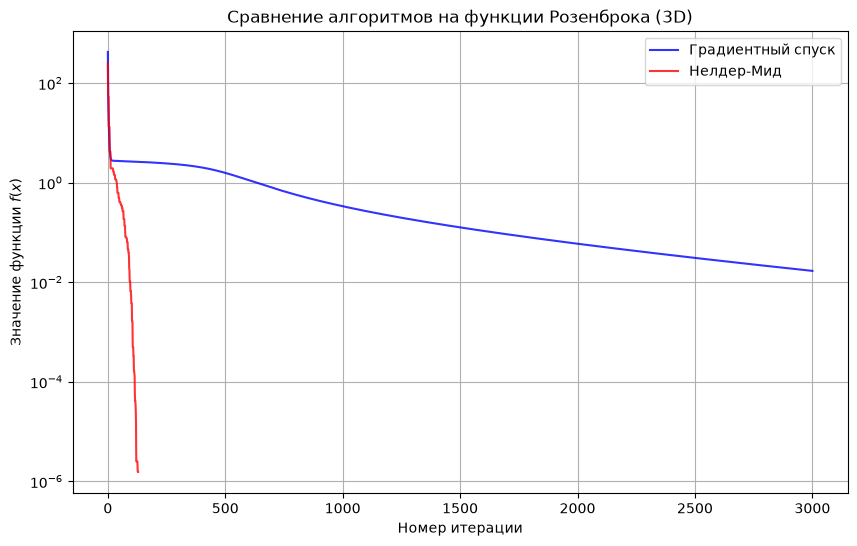

In [ ]:
# Отрисовка сравнительного графика
plt.figure(figsize=(10, 6))

plt.plot(gd_opt_rosen.history_f, label='Градиентный спуск', color='blue', alpha=0.8)
plt.plot(nm_opt_rosen.history_f, label='Нелдер-Мид', color='red', alpha=0.8)

plt.title('Сравнение алгоритмов на функции Розенброка')
plt.xlabel('Номер итерации')
plt.ylabel(r'Значение функции $f(x)$')
plt.yscale('log')
plt.legend()
plt.show()

### Анализ результатов: Тест Розенброка (3D)

* **Градиентный спуск**:
  * **Итог**: Остановлен по лимиту итераций (3000 шагов).
  * **Точка**: $x \approx [0.9406, 0.8844, 0.7816]$ — алгоритм не смог дойти до оптимума $[1, 1, 1]$.
  * **Причина**: На графике видно, как алгоритм мгновенно падает на дно оврага (первые 50 шагов), а затем темп сходимости падает практически до горизонтальной прямой. Вектор градиента гоняет точку между бортами ущелья, делая эффективный шаг вдоль оврага ничтожно малым.
* **Метод Нелдера-Мида**:
  * **Итог**: Сошелся за **128 итераций**.
  * **Точка**: $x^* \approx [1.0002, 1.0002, 1.0004]$ с точностью до $10^{-4}$.
  * **Причина**: Симплекс вытянулся вдоль изгиба долины и за счет операций растяжения двигался по дну без осцилляций, показав превосходство эвристики нулевого порядка над слепым градиентом в невыпуклых оврагах.

## 2.4. 3D-визуализация траекторий в пространстве параметров

Построим траектории движения Градиентного спуска и Нелдера-Мида в фазовом пространстве параметров $(x_0, x_1, x_2)$, чтобы наглядно увидеть геометрию поиска и точку застревания GD.

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Извлекаем координаты траекторий с защитой от ConstructiveNumber
def extract_coords(history):
    xs = [to_real_value(pt[0]) for pt in history]
    ys = [to_real_value(pt[1]) for pt in history]
    zs = [to_real_value(pt[2]) for pt in history]
    return xs, ys, zs

gd_x, gd_y, gd_z = extract_coords(gd_opt_rosen.history_x)
nm_x, nm_y, nm_z = extract_coords(nm_opt_rosen.history_x)

# Создаем 3D-холст
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Траектория Градиентного спуска (синяя тонкая линия с частыми точками)
ax.plot(gd_x, gd_y, gd_z, label='Градиентный спуск (GD)', color='blue', alpha=0.6, linewidth=1.5)

# Траектория Нелдера-Мида (красная пунктирная линия с крупными маркерами вершин)
ax.plot(nm_x, nm_y, nm_z, label='Нелдер-Мид (NM)', color='red', marker='o', markersize=3, linestyle='--', alpha=0.8)

# Стартовая точка
ax.scatter([x0_rosen[0]], [x0_rosen[1]], [x0_rosen[2]], color='black', s=80, label='Старт $x_0$', zorder=5)

# Истинный глобальный минимум
ax.scatter([1.0], [1.0], [1.0], color='gold', edgecolor='black', s=120, marker='*', label='Минимум $(1, 1, 1)$', zorder=5)

# Оформление осей
ax.set_title(r'Траектории оптимизаторов в пространстве переменных $(x_0, x_1, x_2)$', fontsize=14)
ax.set_xlabel('$x_0$')
ax.set_ylabel('$x_1$')
ax.set_zlabel('$x_2$')

# Настройка угла обзора для максимальной наглядности изгиба долины
ax.view_init(elev=20, azim=-60)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()